# FlashEats — Class 7 Challenge
## Model the Business Workflow with Data

### Client question
> **“Show us where in the workflow delay accumulates, how customers react, what interventions we make, and which metrics we should use to improve the project KPI.”**

Do not repeat source discovery, retrieval, or data-cleaning work. Today the goal is to build a useful business-workflow model.

In [1]:
import json, sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

# notebook runs from exercises/, pack folder is next to it
BASE = Path("FlashEats_Classroom_Pack_V2")
if not (BASE / "database" / "flasheats.db").exists():
    raise FileNotFoundError(f"Could not find {BASE.resolve() / 'database' / 'flasheats.db'}. Run from the exercises folder.")
print("Using pack:", BASE)

Using pack: FlashEats_Classroom_Pack_V2


In [2]:
con=sqlite3.connect(BASE/"database"/"flasheats.db")
orders=pd.read_sql("SELECT * FROM orders",con)
customers=pd.read_sql("SELECT * FROM customers",con)
restaurants=pd.read_sql("SELECT * FROM restaurants",con)
drivers=pd.read_sql("SELECT * FROM drivers",con)
tickets=pd.read_csv(BASE/"data"/"support_tickets.csv")
customer_actions=pd.read_csv(BASE/"data"/"customer_app_actions.csv")
interventions=pd.read_csv(BASE/"data"/"order_interventions.csv")
outcomes=pd.read_csv(BASE/"data"/"order_outcomes.csv")
with open(BASE/"data"/"class7_model_brief.json") as f: model_brief=json.load(f)
print("orders",orders.shape,"actions",customer_actions.shape,"interventions",interventions.shape,"outcomes",outcomes.shape)
print("Project KPI:",model_brief["project_kpi"])

orders (1603, 13) actions (2365, 6) interventions (430, 6) outcomes (1600, 6)
Project KPI: Reduce late delivery rate


In [3]:
# Extra sources for the timeline
order_events = pd.read_csv(BASE / "data" / "order_events.csv")
interactions = pd.read_csv(BASE / "data" / "customer_interactions.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
# dispatch comes from the raw API pages saved in Class 5, so the lineage is raw pages -> model
RAW_DIR = BASE / "student_output" / "raw_dispatch"
pages = sorted(RAW_DIR.glob("page_*.json"))
if not pages:
    raise FileNotFoundError(f"No raw dispatch pages in {RAW_DIR}. Run FlashEats_Class5_Starter.ipynb or FlashEats_Class5_Student.ipynb first (Class 5 API pull).")
payloads = [json.loads(p.read_text()) for p in pages]
dispatch = pd.DataFrame([rec for pl in payloads for rec in pl["data"]])
totals = {pl["total_records"] for pl in payloads}
if len(totals) != 1 or len(dispatch) != totals.pop() or not dispatch["order_id"].is_unique:
    raise ValueError("Raw dispatch pages are incomplete or inconsistent. Re-run the Class 5 ingestion.")
print(f"dispatch rebuilt from {len(pages)} raw pages: {len(dispatch)} records")
with open(BASE / "data" / "driver_events.json") as f:
    driver_events = pd.DataFrame([{"driver_id": d["driver_id"], **e} for d in json.load(f) for e in d["events"]])

def to_time(s):
    return pd.to_datetime(s, format="mixed", errors="coerce")

for name, df in {"order_events": order_events, "interactions": interactions, "restaurant_status": restaurant_status,
                 "dispatch": dispatch, "driver_events": driver_events}.items():
    print(f"{name:18s} {df.shape}")

dispatch rebuilt from 32 raw pages: 1600 records
order_events       (4955, 7)
interactions       (497, 6)
restaurant_status  (502, 4)
dispatch           (1600, 9)
driver_events      (10035, 6)


# Challenge 1 — Reconstruct the order lifecycle

Choose 3 orders:
- one delivered on time,
- one delivered late,
- one with an intervention.

Build a timeline with:

`event_time | event_type | actor | source_system`

Include as many lifecycle events as the data supports.

### Hint
Start from one `order_id`, collect events from each source, then sort by time.

In [4]:
base_orders = orders.drop_duplicates("order_id", keep="first").copy()   # 1603 rows -> 1600 orders
for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    base_orders[c] = to_time(base_orders[c])

iv_ids = set(interventions["order_id"])
support_ids = (set(customer_actions.loc[customer_actions["action_type"] == "SUPPORT_OPENED", "order_id"])
               | set(tickets["order_id"].dropna())
               | set(interactions.loc[interactions["interaction_type"] == "SUPPORT_TICKET", "order_id"]))

no_iv = outcomes[~outcomes["order_id"].isin(iv_ids)]
on_time_order = no_iv[no_iv["late_flag"] == 0]["order_id"].iloc[0]
late_order = no_iv[no_iv["late_flag"] == 1]["order_id"].iloc[0]

# for the intervention example I want one where the intervention happened before delivery
# and the customer also contacted support, so the timeline shows the whole chain
cand = interventions.merge(base_orders[["order_id", "actual_delivery_at"]], on="order_id")
cand = cand[(to_time(cand["intervention_at"]) < cand["actual_delivery_at"]) & cand["order_id"].isin(support_ids)]
intervention_order = cand["order_id"].iloc[0]
print("late", late_order, "on-time", on_time_order, "intervention", intervention_order)

late O00002 on-time O00003 intervention O00782


In [5]:
def _events(df, time_col, event_type, actor, source):
    # any source -> the common timeline columns
    return pd.DataFrame({"event_time": to_time(df[time_col]), "event_type": event_type,
                         "actor": actor, "source_system": source})

def build_order_timeline(order_id):
    o = base_orders[base_orders["order_id"] == order_id]
    ev = order_events[order_events["order_id"] == order_id]
    d = dispatch[dispatch["order_id"] == order_id]
    de = driver_events[driver_events["order_id"] == order_id]
    ca = customer_actions[customer_actions["order_id"] == order_id]
    ci = interactions[interactions["order_id"] == order_id]
    tk = tickets[tickets["order_id"] == order_id].drop_duplicates()
    iv = interventions[interventions["order_id"] == order_id]
    rs = restaurant_status[restaurant_status["order_id"] == order_id].drop_duplicates()
    ra = d[d["reassigned_at"].notna()]

    parts = [
        _events(o, "promised_eta", "PROMISED_ETA (target)", "platform", "orders_db"),
        _events(ev, "event_time", ev["event_type"], ev["actor_type"] + ":" + ev["actor_id"].fillna("?"), "order_events/" + ev["source_system"]),
        _events(d, "assigned_at", "DISPATCH_ASSIGNED", "dispatch:" + d["original_driver_id"], "dispatch_api"),
        _events(ra, "reassigned_at", "DISPATCH_REASSIGNED", "dispatch:" + ra["driver_id"], "dispatch_api"),
        _events(d, "estimated_pickup_at", "ESTIMATED_PICKUP (target)", "dispatch", "dispatch_api"),
        _events(d, "current_delivery_eta", "CURRENT_ETA (latest estimate)", "dispatch:" + d["eta_model_version"], "dispatch_api"),
        _events(de, "timestamp", "DRIVER_" + de["type"].str.upper(), "driver:" + de["driver_id"], "driver_app"),
        _events(ca, "action_at", ca["action_type"], "customer:" + ca["customer_id"], "customer_app_actions"),
        _events(ci, "interaction_at", ci["interaction_type"] + (": " + ci["detail"].str.strip()).fillna(""), "customer", "customer_interactions/" + ci["channel"]),
        _events(tk, "created_at", "TICKET: " + tk["category"].str.strip(), "customer", "support_tickets"),
        _events(iv, "intervention_at", "INTERVENTION: " + iv["intervention_type"] + " (" + iv["reason"] + ")", iv["initiated_by"], "order_interventions"),
        _events(rs, "last_updated_at", "RESTAURANT_STATUS: " + rs["status"].str.strip().str.lower(), "restaurant:" + rs["restaurant_id"], "restaurant_status"),
    ]
    tl = pd.concat([p for p in parts if len(p)], ignore_index=True)
    assert tl["event_time"].notna().all(), "every timeline row needs a time"
    return tl.sort_values("event_time", kind="stable").reset_index(drop=True)

for label, oid in [("ON TIME", on_time_order), ("LATE", late_order), ("INTERVENTION", intervention_order)]:
    out = outcomes.loc[outcomes["order_id"] == oid].iloc[0]
    print(f"\n{label}: {oid} | outcome={out['outcome_bucket']} | delay_min={out['delay_min']}")
    display(build_order_timeline(oid))


ON TIME: O00003 | outcome=delivered_on_time | delay_min=-4.41


,event_time,event_type,actor,source_system
0,2026-08-01 19:35:00.000000,ORDER_CREATED,customer:C0855,order_events/order_platform
1,2026-08-01 19:35:00.002443,DISPATCH_ASSIGNED,dispatch:D039,dispatch_api
2,2026-08-01 19:35:00.002443,DRIVER_ASSIGNED,driver:D039,driver_app
3,2026-08-01 19:44:37.017130,DRIVER_GPS_PING,driver:D039,driver_app
4,2026-08-01 19:48:00.000000,RESTAURANT_STATUS: preparing,restaurant:R010,restaurant_status
5,2026-08-01 19:53:00.000000,ESTIMATED_PICKUP (target),dispatch,dispatch_api
6,2026-08-01 19:54:14.031817,DRIVER_GPS_PING,driver:D039,driver_app
7,2026-08-01 19:57:50.820366,PICKED_UP,driver:D039,order_events/order_platform
8,2026-08-01 19:57:50.820366,DRIVER_PICKED_UP,driver:D039,driver_app
9,2026-08-01 20:03:51.046504,DRIVER_GPS_PING,driver:D039,driver_app



LATE: O00002 | outcome=delivered_late | delay_min=3.97


,event_time,event_type,actor,source_system
0,2026-08-01 18:36:00.000000,ORDER_CREATED,customer:C0043,order_events/order_platform
1,2026-08-01 18:37:09.708219,DISPATCH_ASSIGNED,dispatch:D083,dispatch_api
2,2026-08-01 18:37:09.708219,DRIVER_ASSIGNED,driver:D083,driver_app
3,2026-08-01 18:48:50.559938,DRIVER_GPS_PING,driver:D083,driver_app
4,2026-08-01 18:54:00.000000,ESTIMATED_PICKUP (target),dispatch,dispatch_api
5,2026-08-01 18:58:24.735336,PICKED_UP,driver:D083,order_events/order_platform
6,2026-08-01 18:58:24.735336,DRIVER_PICKED_UP,driver:D083,driver_app
7,2026-08-01 19:00:31.411657,DRIVER_GPS_PING,driver:D083,driver_app
8,2026-08-01 19:12:12.263376,DRIVER_GPS_PING,driver:D083,driver_app
9,2026-08-01 19:23:53.115095,DRIVER_GPS_PING,driver:D083,driver_app



INTERVENTION: O00782 | outcome=delivered_late | delay_min=16.86


,event_time,event_type,actor,source_system
0,2026-08-25 18:54:00.000000,ORDER_CREATED,customer:C0559,order_events/order_platform
1,2026-08-25 18:57:14.119525,DISPATCH_ASSIGNED,dispatch:D092,dispatch_api
2,2026-08-25 18:57:14.119525,DRIVER_ASSIGNED,driver:D092,driver_app
3,2026-08-25 19:02:00.000000,INTERVENTION: DRIVER_REASSIGNMENT (driver_unavailable),dispatch,order_interventions
4,2026-08-25 19:11:00.000000,ETA_VIEWED,customer:C0559,customer_app_actions
5,2026-08-25 19:12:00.000000,ESTIMATED_PICKUP (target),dispatch,dispatch_api
6,2026-08-25 19:12:06.370560,DRIVER_GPS_PING,driver:D092,driver_app
7,2026-08-25 19:26:58.621595,DRIVER_GPS_PING,driver:D092,driver_app
8,2026-08-25 19:31:41.016480,PICKED_UP,driver:D092,order_events/order_platform
9,2026-08-25 19:31:41.016480,DRIVER_PICKED_UP,driver:D092,driver_app


,1 created -> assigned,2 assigned -> pickup,3 pickup -> delivered
late_flag,,,
on time,2.3,16.7,45.3
late,2.3,28.8,48.9


pickup later than dispatch's estimated_pickup_at (median min): on time 1.8 | late 13.9


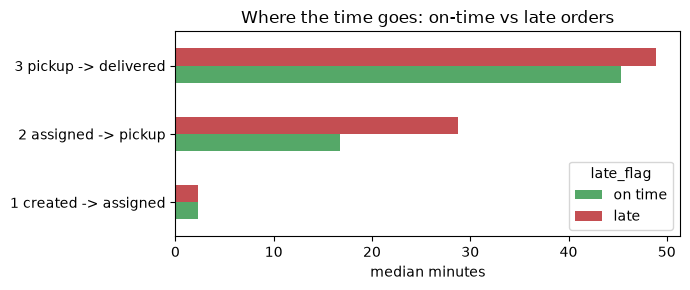

In [6]:
# The same question across all orders: which stage is longer for late orders?
stages = base_orders.merge(dispatch[["order_id", "assigned_at", "estimated_pickup_at"]], on="order_id", validate="one_to_one")
stages = stages.merge(outcomes[["order_id", "late_flag"]], on="order_id", validate="one_to_one")
stages["assigned_at"] = to_time(stages["assigned_at"])
stages["estimated_pickup_at"] = to_time(stages["estimated_pickup_at"])
stages = stages[stages["late_flag"].notna()].copy()

stages["1 created -> assigned"] = (stages["assigned_at"] - stages["created_at"]).dt.total_seconds() / 60
stages["2 assigned -> pickup"] = (stages["pickup_at"] - stages["assigned_at"]).dt.total_seconds() / 60
stages["3 pickup -> delivered"] = (stages["actual_delivery_at"] - stages["pickup_at"]).dt.total_seconds() / 60
stage_cols = ["1 created -> assigned", "2 assigned -> pickup", "3 pickup -> delivered"]

stage_medians = stages.groupby("late_flag")[stage_cols].median().round(1)
stage_medians.index = stage_medians.index.map({0.0: "on time", 1.0: "late"})
display(stage_medians)
print("pickup later than dispatch's estimated_pickup_at (median min): on time",
      round(((stages["pickup_at"] - stages["estimated_pickup_at"]).dt.total_seconds() / 60)[stages["late_flag"] == 0].median(), 1),
      "| late", round(((stages["pickup_at"] - stages["estimated_pickup_at"]).dt.total_seconds() / 60)[stages["late_flag"] == 1].median(), 1))

ax = stage_medians.T.plot(kind="barh", figsize=(7, 3), color=["#55A868", "#C44E52"])
ax.set_xlabel("median minutes")
ax.set_title("Where the time goes: on-time vs late orders")
plt.tight_layout()
plt.show()

`build_order_timeline()` collects every row for the order from each source (the promise from orders, `order_events`, dispatch rebuilt from the raw Class 5 pages, driver app, app actions, interactions, tickets, interventions, restaurant status), puts it in `event_time | event_type | actor | source_system` form and sorts by time. Pickup and delivery appear in both the order platform and driver app, and agree.

- On time, O00003: picked up at 19:57, about 5 min after the estimated pickup, and delivered 4.41 min before the promise.
- Late, O00002: picked up about 4 min after the estimate, then about 49 min on the road, delivered 3.97 min late. This one lost its time on the road.
- Intervention, O00782: a DRIVER_REASSIGNMENT is logged 8 min after creation, but dispatch shows no reassignment and D092 still does the pickup, about 20 min after the estimate. Delivered 16.86 min late.

Across all 1495 orders with an outcome, created to assigned is 2.3 min for both groups, assigned to pickup is 16.7 min (on time) vs 28.8 min (late), and pickup to delivery is 45.3 vs 48.9. Late orders are picked up a median 13.9 min after the estimated pickup, on-time ones 1.8 min. So the delay mostly builds up between assignment and pickup.

# Challenge 2 — Define the canonical project model

Your model must support:
1. customer → orders
2. order → customer interactions
3. order → support interactions
4. order → interventions
5. order → outcome

For each table, document:
- primary key,
- important foreign keys,
- grain.

Then explain why this model is better for the project than mirroring every source-system table.

In [7]:
sources={"orders":orders,"customer_actions":customer_actions,"support_tickets":tickets,"interventions":interventions,"outcomes":outcomes}
for name,df in sources.items():
    print(name,df.shape); display(df.head(2))

orders (1603, 13)


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear


customer_actions (2365, 6)


,action_id,order_id,customer_id,action_type,action_at,channel
0,ACT-00001,O01044,C0249,ETA_VIEWED,2026-08-05T22:11:00,mobile_app
1,ACT-00002,O01334,C0692,ETA_VIEWED,2026-08-01T17:48:00,mobile_app


support_tickets (202, 5)


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.


interventions (430, 6)


,intervention_id,order_id,intervention_type,intervention_at,initiated_by,reason
0,INT-00001,O00781,PRIORITY_DISPATCH,2026-08-22T12:57:00,operations,late_risk
1,INT-00002,O01476,CUSTOMER_CREDIT,2026-08-01T23:46:36.200640,support,support_resolution


outcomes (1600, 6)


,order_id,final_status_norm,delivered_flag,late_flag,delay_min,outcome_bucket
0,O00001,delivered,1,1.0,10.82,delivered_late
1,O00002,delivered,1,1.0,3.97,delivered_late


In [8]:
def pk_check(df, cols):
    cols = [cols] if isinstance(cols, str) else cols
    return f"{'yes' if not df.duplicated(cols).any() else 'NO'} ({df.duplicated(cols).sum()} dup)"

def fk_coverage(df, col, parent_ids):
    s = df[col]
    return round(100 * s.isin(parent_ids).sum() / len(s), 2)

order_ids = set(base_orders["order_id"])
model = pd.DataFrame([
    ["customers", "customers (db)", "customer_id", "-", "one row per customer", len(customers), pk_check(customers, "customer_id"), None],
    ["orders", "orders (db), deduped", "order_id", "customer_id, restaurant_id, driver_id", "one row per order", len(base_orders), pk_check(orders, "order_id") + " before dedup", 100.0],
    ["order_outcomes", "order_outcomes.csv", "order_id", "order_id -> orders", "one row per order", len(outcomes), pk_check(outcomes, "order_id"), fk_coverage(outcomes, "order_id", order_ids)],
    ["order_events", "order_events.csv", "event_id", "order_id, actor_id", "one row per lifecycle event", len(order_events), pk_check(order_events, "event_id"), fk_coverage(order_events, "order_id", order_ids)],
    ["dispatch_assignment", "raw dispatch pages (Class 5)", "order_id", "driver_id, original_driver_id", "one row per order", len(dispatch), pk_check(dispatch, "order_id"), fk_coverage(dispatch, "order_id", order_ids)],
    ["customer_actions", "customer_app_actions.csv", "action_id", "order_id, customer_id", "one row per app action", len(customer_actions), pk_check(customer_actions, "action_id"), fk_coverage(customer_actions, "order_id", order_ids)],
    ["customer_interactions", "customer_interactions.csv", "interaction_id (+ order_id)", "order_id", "one row per interaction", len(interactions), pk_check(interactions, "interaction_id"), fk_coverage(interactions, "order_id", order_ids)],
    ["support_tickets", "support_tickets.csv", "ticket_id", "order_id (nullable)", "one row per ticket", len(tickets), pk_check(tickets, "ticket_id"), fk_coverage(tickets, "order_id", order_ids)],
    ["interventions", "order_interventions.csv", "intervention_id", "order_id", "one row per intervention", len(interventions), pk_check(interventions, "intervention_id"), fk_coverage(interventions, "order_id", order_ids)],
], columns=["entity", "source", "primary_key", "foreign_keys", "grain", "rows", "pk_unique", "order_fk_coverage_pct"])
display(model)

print("customer_interactions is (interaction_id, order_id) unique?", pk_check(interactions, ["interaction_id", "order_id"]))
print("customer_actions.customer_id agrees with orders.customer_id:",
      int((customer_actions.merge(base_orders[["order_id", "customer_id"]], on="order_id", suffixes=("", "_o"))
           .pipe(lambda d: d["customer_id"] == d["customer_id_o"])).mean() * 100), "%")
print("orders per ordering customer:", base_orders.groupby("customer_id").size().describe()[["count", "mean", "max"]].round(2).to_dict())
print("app action types:", customer_actions["action_type"].value_counts().to_dict())
print("interaction types:", interactions["interaction_type"].value_counts().to_dict())

,entity,source,primary_key,foreign_keys,grain,rows,pk_unique,order_fk_coverage_pct
0,customers,customers (db),customer_id,-,one row per customer,900,yes (0 dup),NaN
1,orders,"orders (db), deduped",order_id,"customer_id, restaurant_id, driver_id",one row per order,1600,NO (3 dup) before dedup,100.00
2,order_outcomes,order_outcomes.csv,order_id,order_id -> orders,one row per order,1600,yes (0 dup),100.00
3,order_events,order_events.csv,event_id,"order_id, actor_id",one row per lifecycle event,4955,yes (0 dup),100.00
4,dispatch_assignment,raw dispatch pages (Class 5),order_id,"driver_id, original_driver_id",one row per order,1600,yes (0 dup),100.00
5,customer_actions,customer_app_actions.csv,action_id,"order_id, customer_id",one row per app action,2365,yes (0 dup),100.00
6,customer_interactions,customer_interactions.csv,interaction_id (+ order_id),order_id,one row per interaction,497,NO (3 dup),100.00
7,support_tickets,support_tickets.csv,ticket_id,order_id (nullable),one row per ticket,202,NO (1 dup),98.51
8,interventions,order_interventions.csv,intervention_id,order_id,one row per intervention,430,yes (0 dup),100.00


customer_interactions is (interaction_id, order_id) unique? yes (0 dup)
customer_actions.customer_id agrees with orders.customer_id: 100 %
orders per ordering customer: {'count': 727.0, 'mean': 2.2, 'max': 8.0}
app action types: {'ETA_VIEWED': 2217, 'SUPPORT_OPENED': 138, 'CANCEL_ATTEMPTED': 10}
interaction types: {'SUPPORT_TICKET': 177, 'ETA_VIEW': 155, 'ORDER_STATUS_REFRESH': 111, 'HELP_OPENED': 54}


In [9]:
# Two places record interventions. Do they agree?
ev_iv = order_events[order_events["source_system"] == "interventions"]
both = ev_iv.merge(interventions, on="order_id")
print("intervention events in order_events:", len(ev_iv), "on", ev_iv["order_id"].nunique(), "orders")
print("rows in order_interventions.csv:", len(interventions), "on", interventions["order_id"].nunique(), "orders")
print("orders in both:", both["order_id"].nunique())
print("same intervention type where both exist:", int((both["event_type"] == both["intervention_type"]).sum()), "of", len(both))
print("order_events intervention types:", ev_iv["event_type"].value_counts().to_dict())

# does a DRIVER_REASSIGNMENT intervention show up as a reassignment in dispatch?
ra_iv = interventions[interventions["intervention_type"] == "DRIVER_REASSIGNMENT"].merge(dispatch, on="order_id")
print("DRIVER_REASSIGNMENT interventions:", len(ra_iv), "| dispatch shows a reassignment for:", int(ra_iv["reassigned_at"].notna().sum()))
print("dispatch reassignments in total:", int(dispatch["reassigned_at"].notna().sum()))

# order_events vs orders table for the core lifecycle
core = order_events.pivot_table(index="order_id", columns="event_type", values="event_time", aggfunc="first")
same_pickup = (to_time(core["PICKED_UP"]) == base_orders.set_index("order_id")["pickup_at"].reindex(core.index)).sum()
print("order_events PICKED_UP == orders.pickup_at:", int(same_pickup), "of", int(core["PICKED_UP"].notna().sum()))

intervention events in order_events: 260 on 260 orders
rows in order_interventions.csv: 430 on 430 orders
orders in both: 75
same intervention type where both exist: 15 of 75
order_events intervention types: {'DRIVER_REASSIGNMENT': 79, 'ETA_MESSAGE': 61, 'RESTAURANT_CONTACT': 56, 'PRIORITY_DISPATCH': 41, 'REFUND_OFFER': 23}
DRIVER_REASSIGNMENT interventions: 155 | dispatch shows a reassignment for: 8
dispatch reassignments in total: 95
order_events PICKED_UP == orders.pickup_at: 1600 of 1600


| Entity | Primary key | Foreign keys | Grain | Note |
|---|---|---|---|---|
| customers | `customer_id` | - | one customer | 900, of which 727 ordered |
| orders | `order_id` | `customer_id`, `restaurant_id`, `driver_id` | one order | 3 duplicate rows removed |
| order_outcomes | `order_id` | `order_id` | one order | `delay_min` matches the orders table |
| order_events | `event_id` | `order_id` | one lifecycle event | PICKED_UP matches `orders.pickup_at` |
| dispatch_assignment | `order_id` | `driver_id`, `original_driver_id` | one order | rebuilt from the raw Class 5 pages |
| customer_actions | `action_id` | `order_id`, `customer_id` | one app action | customer_id agrees with orders |
| customer_interactions | `interaction_id` + `order_id` | `order_id` | one interaction | `interaction_id` alone isn't unique |
| support_tickets | `ticket_id` | `order_id` (nullable) | one ticket | 1 duplicate, 3 without an order |
| interventions | `intervention_id` | `order_id` | one intervention | at most one per order here |

Customer 1-N orders; order 1-1 outcome and dispatch; order 1-N events, actions, interactions, tickets and interventions. Everything joins on `order_id`.

`order_events` also logs interventions, but it mostly doesn't match `order_interventions.csv` (only 75 orders are in both). I use the CSV since it has IDs, initiator and reason, and I'd ask the tooling owner which log is right.

Why not mirror every source table: each analysis would redo the same dedups and joins and deal with things like `ETA_VIEW` vs `ETA_VIEWED` in two files. With orders as the hub and a few child tables at a clear grain, each question is one aggregate-then-join, and the data problems get handled once.

# Challenge 3 — Build interaction → intervention → outcome

Create one order-level table containing:

`order_id, customer_id, support_opened, cancel_attempted, intervention_count, intervention_types, final_status, late_flag, delay_min`

Answer:
1. How many late orders had support interaction?
2. How many orders received intervention?
3. Which intervention is most common?
4. Which frustrated journeys had no intervention?

### Hint
Aggregate one-to-many tables before joining them to order-level outcomes.

In [10]:
def join_check(left, right, name, **kw):
    # left join + print the row count so a fan-out shows up straight away
    out = left.merge(right, how="left", validate="one_to_one", **kw)
    print(f"after joining {name:18s}: {len(out)} rows")
    return out

act = customer_actions.pivot_table(index="order_id", columns="action_type", values="action_id", aggfunc="count", fill_value=0).reset_index()
act.columns.name = None
tick_orders = pd.DataFrame({"order_id": sorted(set(tickets["order_id"].dropna()) | set(interactions.loc[interactions["interaction_type"] == "SUPPORT_TICKET", "order_id"])), "has_ticket": 1})
iv_agg = (interventions.groupby("order_id")
          .agg(intervention_count=("intervention_id", "count"),
               intervention_types=("intervention_type", lambda s: ", ".join(sorted(s.unique()))),
               first_intervention_at=("intervention_at", "min"))
          .reset_index())

om = base_orders[["order_id", "customer_id", "restaurant_id", "actual_delivery_at"]]
print("orders:", len(om))
om = join_check(om, act[["order_id", "SUPPORT_OPENED", "CANCEL_ATTEMPTED"]], "action flags", on="order_id")
om = join_check(om, tick_orders, "tickets", on="order_id")
om = join_check(om, iv_agg, "interventions", on="order_id")
om = join_check(om, outcomes[["order_id", "final_status_norm", "late_flag", "delay_min"]], "outcomes", on="order_id")

om["support_opened"] = ((om["SUPPORT_OPENED"].fillna(0) > 0) | (om["has_ticket"].fillna(0) > 0)).astype(int)
om["cancel_attempted"] = (om["CANCEL_ATTEMPTED"].fillna(0) > 0).astype(int)
om["intervention_count"] = om["intervention_count"].fillna(0).astype(int)
om["intervention_types"] = om["intervention_types"].fillna("none")
om["iv_before_delivery"] = to_time(om["first_intervention_at"]) < om["actual_delivery_at"]
om = om.rename(columns={"final_status_norm": "final_status"})

order_model = om[["order_id", "customer_id", "support_opened", "cancel_attempted", "intervention_count",
                  "intervention_types", "final_status", "late_flag", "delay_min"]]
assert order_model["order_id"].is_unique and len(order_model) == 1600
display(order_model.head(10))

orders: 1600
after joining action flags      : 1600 rows
after joining tickets           : 1600 rows
after joining interventions     : 1600 rows


after joining outcomes          : 1600 rows


,order_id,customer_id,support_opened,cancel_attempted,intervention_count,intervention_types,final_status,late_flag,delay_min
0,O00001,C0168,1,0,1,DRIVER_REASSIGNMENT,delivered,1.0,10.82
1,O00002,C0043,0,0,0,none,delivered,1.0,3.97
2,O00003,C0855,0,0,0,none,delivered,0.0,-4.41
3,O00004,C0229,0,0,0,none,cancelled,NaN,NaN
4,O00005,C0040,0,0,0,none,delivered,1.0,21.02
5,O00006,C0152,0,0,0,none,delivered,1.0,7.30
6,O00007,C0875,0,0,0,none,delivered,1.0,4.27
7,O00008,C0223,1,0,1,CUSTOMER_CREDIT,delivered,1.0,26.86
8,O00009,C0685,0,0,0,none,delivered,1.0,0.69
9,O00010,C0530,0,0,0,none,delivered,0.0,-5.79


In [11]:
# sanity check: outcomes.delay_min should match what I compute from the orders table
recalc = ((base_orders["actual_delivery_at"] - base_orders["promised_eta"]).dt.total_seconds() / 60).round(2)
chk = outcomes.merge(base_orders[["order_id"]].assign(recalc=recalc.values), on="order_id")
print("outcomes.delay_min matches orders:", int(((chk["delay_min"] - chk["recalc"]).abs() < 0.01).sum()), "of", int(chk["delay_min"].notna().sum()))

late = om[om["late_flag"] == 1]
print("\n1) late orders:", len(late))
print("   with any support contact:", int(late["support_opened"].sum()), f"({100 * late['support_opened'].mean():.1f}%)")
print("   by source -> app SUPPORT_OPENED:", int((late["SUPPORT_OPENED"].fillna(0) > 0).sum()),
      "| ticket (tickets.csv or interactions):", int(late["has_ticket"].fillna(0).sum()),
      "| both:", int(((late["SUPPORT_OPENED"].fillna(0) > 0) & (late["has_ticket"].fillna(0) > 0)).sum()))
print("   support contact on non-late orders:", int(om.loc[om["late_flag"] != 1, "support_opened"].sum()))
print("   app SUPPORT_OPENED on non-late orders:", int((om.loc[om["late_flag"] != 1, "SUPPORT_OPENED"].fillna(0) > 0).sum()))

print("\n2) orders with an intervention:", int((om["intervention_count"] > 0).sum()), "| max per order:", om["intervention_count"].max())
print("\n3) intervention types:")
display(interventions["intervention_type"].value_counts().to_frame("interventions"))

frustrated = om[(om["support_opened"] == 1) | (om["cancel_attempted"] == 1)]
no_help = frustrated[frustrated["intervention_count"] == 0]
print("4) frustrated journeys (support contact or cancel attempt):", len(frustrated), "| with no intervention:", len(no_help))
display(no_help.groupby("final_status").agg(orders=("order_id", "count"), late=("late_flag", "sum")))
print("cancel attempts with no intervention:", int(no_help["cancel_attempted"].sum()), "of", int(frustrated["cancel_attempted"].sum()))
display(no_help.sort_values("delay_min", ascending=False).head(8)[["order_id", "customer_id", "support_opened", "cancel_attempted", "final_status", "delay_min"]])

outcomes.delay_min matches orders:

 1495 of 1495

1) late orders: 843
   with any support contact: 258 (30.6%)
   by source -> app SUPPORT_OPENED: 138 | ticket (tickets.csv or interactions): 163 | both: 43
   support contact on non-late orders: 35
   app SUPPORT_OPENED on non-late orders: 0

2) orders with an intervention: 430 | max per order: 1

3) intervention types:


,interventions
intervention_type,
DRIVER_REASSIGNMENT,155
RESTAURANT_CONTACT,116
PRIORITY_DISPATCH,95
CUSTOMER_CREDIT,64


4) frustrated journeys (support contact or cancel attempt): 294 | with no intervention: 219


,orders,late
final_status,,
delivered,219,192.0


cancel attempts with no intervention: 7 of 10


,order_id,customer_id,support_opened,cancel_attempted,final_status,delay_min
193,O00194,C0771,1,0,delivered,38.34
736,O00737,C0824,1,0,delivered,36.28
302,O00303,C0411,1,0,delivered,33.16
210,O00211,C0629,1,0,delivered,32.38
1234,O01235,C0772,1,0,delivered,32.00
976,O00977,C0254,1,0,delivered,31.92
994,O00995,C0746,1,0,delivered,31.72
1196,O01197,C0032,1,0,delivered,31.61


I built the one-to-many tables (actions, tickets, interventions) as one row per order first, then left-joined them onto the 1600 orders. The row count stayed at 1600 after every join (printed above), and `validate="one_to_one"` would raise an error if any join fanned out. My definitions: `support_opened` = the app logged SUPPORT_OPENED, or there is a ticket in `support_tickets.csv` or a SUPPORT_TICKET in `customer_interactions`. `cancel_attempted` = the app logged CANCEL_ATTEMPTED. `late_flag` and `delay_min` come from `order_outcomes`, and I checked that they match the orders table.

1. **Late orders with support interaction:** 258 of 843 late orders (30.6%). By source: 138 have the app SUPPORT_OPENED action, 163 have a ticket, and only 43 have both. The two support sources overlap much less than I expected, so it matters which one you count. Strangely, the app SUPPORT_OPENED action never appears on an order that wasn't late.
2. **Orders with an intervention:** 430, each with exactly one.
3. **Most common intervention:** DRIVER_REASSIGNMENT (155), then RESTAURANT_CONTACT (116), PRIORITY_DISPATCH (95) and CUSTOMER_CREDIT (64).
4. **Frustrated journeys with no intervention:** I call a journey frustrated if the customer contacted support or tried to cancel. That gives 294 journeys, and 219 of them got no intervention at all, 192 of which were late. 7 of the 10 customers who tried to cancel got no intervention. The worst are listed above, e.g. O00194 (38.34 min late, support contact, nothing done).

# Challenge 4 — Select 3–5 business metrics

Project KPI: **Reduce Late Delivery Rate**.

For each chosen metric, document:
- metric name,
- formula,
- grain,
- why it matters,
- relationship to the project KPI.

At least one metric must represent:
- an outcome,
- a customer interaction,
- an intervention.

In [12]:
valid_outcomes = om[om["late_flag"].notna()]
late = valid_outcomes[valid_outcomes["late_flag"] == 1]

pick = stages.assign(pickup_slip=(stages["pickup_at"] - stages["estimated_pickup_at"]).dt.total_seconds() / 60)

metrics = pd.DataFrame([
    {"metric": "Late Delivery Rate", "type": "outcome",
     "formula": "late orders / delivered orders with a delivery time",
     "grain": "order", "value": f"{100 * valid_outcomes['late_flag'].mean():.1f}% ({int(valid_outcomes['late_flag'].sum())}/{len(valid_outcomes)})"},
    {"metric": "Late Pickup Rate", "type": "workflow driver",
     "formula": "orders picked up > 10 min after dispatch estimated_pickup_at / delivered orders with a time",
     "grain": "order", "value": f"{100 * (pick['pickup_slip'] > 10).mean():.1f}% ({int((pick['pickup_slip'] > 10).sum())}/{len(pick)})"},
    {"metric": "Support Contact Rate", "type": "customer interaction",
     "formula": "orders with app SUPPORT_OPENED or a support ticket / all orders",
     "grain": "order", "value": f"{100 * om['support_opened'].mean():.1f}% ({int(om['support_opened'].sum())}/{len(om)})"},
    {"metric": "Pre-delivery Intervention Coverage", "type": "intervention",
     "formula": "late orders with an intervention before actual delivery / late orders",
     "grain": "order (late only)", "value": f"{100 * late['iv_before_delivery'].mean():.1f}% ({int(late['iv_before_delivery'].sum())}/{len(late)})"},
])
display(metrics)
print("late rate when pickup slip > 10 min:", f"{100 * pick.loc[pick['pickup_slip'] > 10, 'late_flag'].mean():.1f}%",
      "| when <= 10 min:", f"{100 * pick.loc[pick['pickup_slip'] <= 10, 'late_flag'].mean():.1f}%")

,metric,type,formula,grain,value
0,Late Delivery Rate,outcome,late orders / delivered orders with a delivery time,order,56.4% (843/1495)
1,Late Pickup Rate,workflow driver,orders picked up > 10 min after dispatch estimated_pickup_at / delivered orders with a time,order,42.0% (628/1495)
2,Support Contact Rate,customer interaction,orders with app SUPPORT_OPENED or a support ticket / all orders,order,18.3% (293/1600)
3,Pre-delivery Intervention Coverage,intervention,late orders with an intervention before actual delivery / late orders,order (late only),24.2% (204/843)


late rate when pickup slip > 10 min: 96.5% | when <= 10 min: 27.3%


| Metric | Formula | Grain | Value now | Why it matters | Link to the KPI |
|---|---|---|---|---|---|
| Late Delivery Rate (outcome) | late orders / delivered orders with a delivery time | order | 56.4% (843/1495) | it *is* the project KPI | the thing we want to reduce |
| Late Pickup Rate (workflow driver) | orders picked up > 10 min after dispatch's `estimated_pickup_at` / delivered orders with a time | order | 42.0% (628/1495) | Challenge 1 shows the delay builds up before pickup | 96.5% of late-pickup orders end up late vs 27.3% of the rest, so it is a leading indicator |
| Support Contact Rate (customer interaction) | orders with app SUPPORT_OPENED or a ticket / all orders | order | 18.3% (293/1600) | the cost and experience side of lateness | should fall when lateness falls; if it doesn't, the problem is ETA communication |
| Pre-delivery Intervention Coverage (intervention) | late orders with an intervention *before* delivery / late orders | order (late orders) | 24.2% (204/843) | how often ops acts while it can still help | an intervention can only affect the KPI if it happens before delivery |

I left out things like average ETA views per order. They are easy to compute, but I couldn't tie them to a decision.

# Challenge 5 — Investigate the workflow with joins and aggregations

Answer at least three:

A. Do orders with support interactions have higher delay?  
B. What is late rate with vs without intervention?  
C. Which intervention type is associated with the lowest late rate?  
D. Which restaurants contribute the largest number of late orders?  
E. Which journeys show support interaction + intervention + still late?

For every answer, add one sentence:

> **What does this tell the business, and what does it NOT prove?**

In [13]:
def outcome_summary(df, by):
    d = df[df["late_flag"].notna()]
    return d.groupby(by).agg(orders=("order_id", "count"), late_rate_pct=("late_flag", lambda s: round(100 * s.mean(), 1)),
                             mean_delay=("delay_min", "mean"), median_delay=("delay_min", "median")).round(1)

print("A) support contact vs delay")
display(outcome_summary(om, "support_opened"))
print("   ticket only (ignoring the app SUPPORT_OPENED action):")
display(outcome_summary(om.assign(has_ticket=om["has_ticket"].fillna(0).astype(int)), "has_ticket"))

print("B) with vs without intervention")
om["iv_group"] = "no intervention"
om.loc[om["intervention_count"] > 0, "iv_group"] = "after delivery"
om.loc[om["iv_before_delivery"], "iv_group"] = "before delivery"
display(outcome_summary(om.assign(any_iv=om["intervention_count"] > 0), "any_iv"))
display(outcome_summary(om, "iv_group"))

A) support contact vs delay


,orders,late_rate_pct,mean_delay,median_delay
support_opened,,,,
0,1203,48.6,0.8,-0.2
1,292,88.4,12.7,12.3


   ticket only (ignoring the app SUPPORT_OPENED action):


,orders,late_rate_pct,mean_delay,median_delay
has_ticket,,,,
0,1298,52.4,1.9,0.5
1,197,82.7,11.0,11.4


B) with vs without intervention


,orders,late_rate_pct,mean_delay,median_delay
any_iv,,,,
False,1091,56.4,3.1,1.4
True,404,56.4,3.2,1.5


,orders,late_rate_pct,mean_delay,median_delay
iv_group,,,,
after delivery,45,53.3,-0.9,0.6
before delivery,359,56.8,3.8,1.6
no intervention,1091,56.4,3.1,1.4


In [14]:
print("C) late rate by intervention type")
iv_detail = interventions.merge(om[["order_id", "late_flag", "delay_min", "actual_delivery_at"]], on="order_id", validate="many_to_one")
iv_detail["after_delivery"] = to_time(iv_detail["intervention_at"]) > iv_detail["actual_delivery_at"]
by_type = iv_detail[iv_detail["late_flag"].notna()].groupby("intervention_type").agg(
    orders=("order_id", "count"), late_rate_pct=("late_flag", lambda s: round(100 * s.mean(), 1)),
    median_delay=("delay_min", "median"), pct_after_delivery=("after_delivery", lambda s: round(100 * s.mean(), 1)))
display(by_type.sort_values("late_rate_pct"))
display(iv_detail.groupby(["intervention_type", "initiated_by"]).size().to_frame("n"))

print("D) restaurants with the most late orders")
rest = om[om["late_flag"].notna()].groupby("restaurant_id").agg(orders=("order_id", "count"), late_orders=("late_flag", "sum"),
                                                                 late_rate_pct=("late_flag", lambda s: round(100 * s.mean(), 1)))
rest["late_orders"] = rest["late_orders"].astype(int)
display(rest.sort_values(["late_orders", "late_rate_pct"], ascending=False).head(8))
print("restaurants:", len(rest), "| late orders from top 5:", int(rest.nlargest(5, "late_orders")["late_orders"].sum()), "of", int(rest["late_orders"].sum()))

print("E) support + intervention + still late")
e = om[(om["support_opened"] == 1) & (om["intervention_count"] > 0) & (om["late_flag"] == 1)]
print("journeys:", len(e), "| of which intervention came before delivery:", int(e["iv_before_delivery"].sum()))
display(e["intervention_types"].value_counts().to_frame("journeys"))
display(e.sort_values("delay_min", ascending=False).head(5)[["order_id", "intervention_types", "delay_min"]])

C) late rate by intervention type


,orders,late_rate_pct,median_delay,pct_after_delivery
intervention_type,,,,
PRIORITY_DISPATCH,86,51.2,0.33,0.0
RESTAURANT_CONTACT,108,52.8,0.80,0.0
DRIVER_REASSIGNMENT,147,57.8,1.60,0.0
CUSTOMER_CREDIT,63,66.7,2.93,71.4


,,n
intervention_type,initiated_by,
CUSTOMER_CREDIT,support,64
DRIVER_REASSIGNMENT,dispatch,155
PRIORITY_DISPATCH,operations,95
RESTAURANT_CONTACT,support,116


D) restaurants with the most late orders


,orders,late_orders,late_rate_pct
restaurant_id,,,
R050,35,22,62.9
R024,25,20,80.0
R051,29,20,69.0
R004,30,20,66.7
R023,32,20,62.5
R030,38,20,52.6
R045,29,19,65.5
R011,31,19,61.3


restaurants: 60 | late orders from top 5: 102 of 841
E) support + intervention + still late
journeys: 67 | of which intervention came before delivery: 64


,journeys
intervention_types,
DRIVER_REASSIGNMENT,26
CUSTOMER_CREDIT,15
PRIORITY_DISPATCH,14
RESTAURANT_CONTACT,12


,order_id,intervention_types,delay_min
100,O00101,CUSTOMER_CREDIT,85.51
197,O00198,RESTAURANT_CONTACT,35.23
496,O00497,PRIORITY_DISPATCH,31.78
612,O00613,PRIORITY_DISPATCH,27.18
7,O00008,CUSTOMER_CREDIT,26.86


**A. Support contact vs delay.** Orders with support contact are 88.4% late (mean delay 12.7 min) vs 48.6% (0.8 min) without; tickets only: 82.7% vs 52.4%. This tells the business that support volume tracks how bad lateness is. It does not prove contact affects anything: lateness is what drives people to support, and the app SUPPORT_OPENED action only shows up on late orders.

**B. With vs without intervention.** 56.4% vs 56.4% (404 vs 1091 orders), and 56.8% when the intervention came before delivery. So interventions as used now don't go with fewer late orders. That doesn't prove they don't work, because ops picks orders that already look risky and there's no comparison group.

**C. Lowest late rate by type.** PRIORITY_DISPATCH 51.2% (86), RESTAURANT_CONTACT 52.8% (108), DRIVER_REASSIGNMENT 57.8% (147), CUSTOMER_CREDIT 66.7% (63). Priority dispatch is the first one I'd test properly. It doesn't prove it's the best, since each type is used for different reasons, and 71.4% of credits happen after delivery, where they can't change lateness.

**D. Restaurants with most late orders.** R050 (22 of 35), then R024, R051, R004, R023 and R030 with 20 each; R024 is 80.0% late. That's a list of where to look first. It doesn't prove these kitchens are slow: volumes are small (25 to 38 orders) and I can't separate prep time from driver wait.

**E. Support + intervention + still late.** 67 journeys, 64 of them with the intervention before delivery. They are a good sample for case reviews since they cost support time and an intervention. It doesn't show the interventions failed, as I have nothing to compare these orders against.

# Challenge 6 — Connect the model to the KPI

Create a one-page project view:

`PROJECT KPI → OUTCOME METRIC → WORKFLOW/DRIVER METRICS → INTERVENTIONS → DATA SOURCES/EVENTS`

Answer:
1. Which metrics are directly controllable by operations?
2. Which are outcomes?
3. Which missing event limits the model most?
4. What would you instrument next?

Final deliverable:
- core entities,
- key events,
- relationships,
- 3–5 metrics,
- KPI linkage,
- one modelling limitation.

```
KPI              Reduce Late Delivery Rate
OUTCOME          Late Delivery Rate 56.4% (843/1495)
DRIVERS          Late Pickup Rate 42.0%; assigned->pickup 28.8 min (late) vs 16.7 (on time)
                 Support Contact Rate 18.3%
INTERVENTIONS    PRIORITY_DISPATCH, DRIVER_REASSIGNMENT, RESTAURANT_CONTACT (before delivery)
                 CUSTOMER_CREDIT (mostly after delivery, recovery)
                 Pre-delivery Intervention Coverage 24.2%
SOURCES          orders_db, order_events, raw dispatch pages, driver_app, restaurant_status,
                 customer_app_actions, customer_interactions, support_tickets,
                 order_interventions, order_outcomes
```

1. Controllable by ops: which interventions happen and when (pre-delivery coverage), dispatch actions, contacting restaurants. Late pickup rate only partly, since it also depends on the kitchen.
2. Outcomes: Late Delivery Rate and delay minutes. Support contacts and cancel attempts are customer-side outcomes.
3. Biggest missing event: food ready / driver arrived at restaurant. The delay sits between assignment and pickup and I can't split it.
4. Instrument next: `food_ready_at` with a status history, a driver-arrival event at the restaurant, one intervention log with when the action took effect, and every ETA shown to the customer.

Final deliverable:
- Entities: customer, order, outcome, dispatch assignment, order event, customer action/interaction, ticket, intervention.
- Key events: created, assigned, (missing: arrived, food ready), picked up, delivered; plus ETA viewed, support opened, cancel attempted, intervention.
- Relationships: customer 1-N orders; order 1-1 outcome and dispatch; order 1-N the rest, joined on `order_id` after aggregating.
- Metrics: the four in Challenge 4 (56.4%, 42.0%, 18.3%, 24.2%).
- KPI link: orders with a late pickup end up late 96.5% of the time vs 27.3% otherwise, so pickup is where ops should act.
- Limitation: two intervention logs that mostly disagree and no comparison group, so the model can describe interventions but can't say whether they reduce lateness.

# Final reflection

A strong solution does not produce the largest schema.

It produces the **smallest useful model that explains the workflow and supports the project KPI**.

In [15]:
con.close()